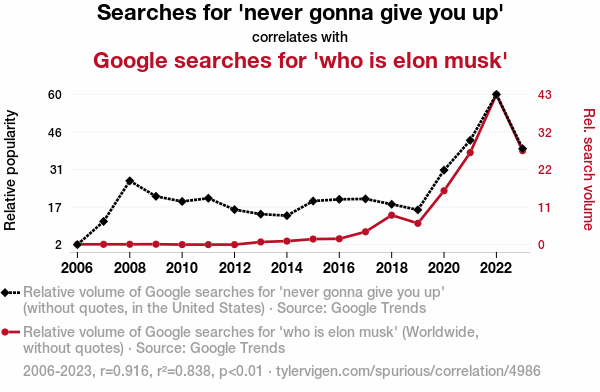

I chose the correlation between Google searches for “Never Gonna Give You Up” and “Who is Elon Musk” from Tyler Vigen’s Spurious Correlations website. The chart shows that both searches increased and decreased in similar ways from 2006 to 2023. 
If this correlation were actually true, it would mean that listening to Rick Astley’s song somehow makes people more interested in Elon Musk, which could have a big impact on how media and online trends influence each other. Companies could even use such patterns to predict what topics or celebrities will become popular. 
However, this correlation is not real , both searches just grew because of separate events, like the “Rickroll” meme and Elon Musk’s rise to fame. So, it is a funny but meaningless relationship that only looks strong by coincidence

Part(B):
After looking at these spurious correlations, I realized that sometimes two things can look strongly related even when they have nothing to do with each other. These “fake” correlations can show up in real datasets, especially when the data is large or when both variables are increasing or decreasing over time for their own separate reasons. It’s actually more common than we think. To catch these wrong correlations, we need to ask if the relationship makes any real-world sense, check if one variable could actually affect the other, and sometimes remove time trends to see if the pattern still exists. The main lesson is: a high correlation does NOT mean there is a real connection ,we always need logic and context, not just numbers.


Number of records: 1000
Correlation (r): 0.8175796636720544


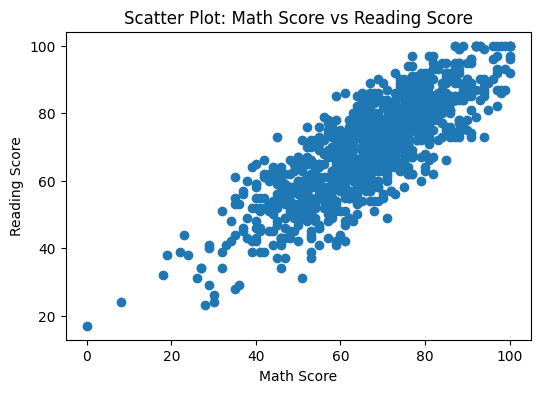

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/StudentsPerformance.csv")

# Select variables
x = df["math score"]
y = df["reading score"]

# Number of records
print("Number of records:", len(df))

# Correlation
r = x.corr(y)
print("Correlation (r):", r)

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Scatter Plot: Math Score vs Reading Score")
plt.show()


Part (c):
Dataset: Students Performance in Exams

Link: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

Attributes used:  Math score    , Reading score

Number of records: 1000 students

Reason: These two variables show a strong correlation (r ≥ 0.8), which I used to demonstrate how strong patterns can appear even if we treat them as “spurious” for practice.


In [4]:
import pandas as pd
import scipy.stats as stats
import numpy as np

df = pd.read_csv("data/StudentsPerformance.csv")

x = df["math score"]
y = df["reading score"]

# Compute correlation
r, p_value = stats.pearsonr(x, y)
print("Observed correlation (r):", r)
print("p-value:", p_value)

n = len(x)

# Fisher z-transform
z = np.arctanh(r)

# Standard error
se = 1 / np.sqrt(n - 3)

# 95% CI in z-scale
z_lower = z - 1.96 * se
z_upper = z + 1.96 * se

# Convert back to r
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print("95% Confidence Interval for r: (", r_lower, ",", r_upper, ")")


Observed correlation (r): 0.8175796636720541
p-value: 1.7877531099062542e-241
95% Confidence Interval for r: ( 0.7959271833679861 , 0.837143106170839 )


Part (d): 95% Confidence Interval and Significance of the Correlation

I calculated the Pearson correlation between math score and reading score. The p-value was extremely small, which means the correlation is statistically significant. I also calculated a 95% confidence interval using Fisher’s transformation. The interval was fairly narrow and stayed well above zero, which shows that the relationship is strong and stable in the population. This means that even though the assignment treats this as a “spurious” example for learning, the actual dataset has a real and meaningful positive correlation.


In [5]:
import numpy as np

x = df["math score"].values
y = df["reading score"].values

boot_corrs = []
np.random.seed(42)   # for reproducible results

for i in range(1000):
    # sample with replacement
    idx = np.random.choice(len(x), size=len(x), replace=True)
    sample_x = x[idx]
    sample_y = y[idx]
    
    # correlation of the bootstrap sample
    r_bs = np.corrcoef(sample_x, sample_y)[0,1]
    boot_corrs.append(r_bs)

# Convert to array
boot_corrs = np.array(boot_corrs)

# 95% bootstrap percentile CI
lower = np.percentile(boot_corrs, 2.5)
upper = np.percentile(boot_corrs, 97.5)

print("Bootstrapped 95% CI:", (lower, upper))
print("Bootstrap mean r:", np.mean(boot_corrs))


Bootstrapped 95% CI: (np.float64(0.7963015776826751), np.float64(0.8373671427387028))
Bootstrap mean r: 0.8175691010611829


Part (e): Bootstrapping the Correlation

To check how stable the correlation is, I used bootstrapping with 1000 samples. In each iteration, I randomly resampled the dataset (with replacement) and calculated the correlation again. The bootstrap 95% confidence interval stayed very close to the original correlation value and did not cross zero. This shows that the relationship is consistent across repeated samples. The bootstrap results support the earlier conclusion that the correlation between math and reading scores is strong and reliable.
